# `ingestion/parse.py` — Validation Walkthrough

Steps through each major output of the parser against the FE 501s repair manual.

In [1]:
import sys
sys.path.insert(0, "..")   # make ingestion package importable from research/

import pypdf
from ingestion.parse import parse_manual, parse_toc

PDF = "../manuals/FE_501s_2026_US_en_Bundle_RM_069969-000001_05sq_m1du.pdf"

## 1. Table of Contents

`parse_toc` walks the TOC pages and returns every entry as `{number, title, page}`.

In [2]:
pdf = pypdf.PdfReader(PDF)
toc = parse_toc(pdf)

print(f"Total TOC entries: {len(toc)}")
print("\nFirst 5:")
for e in toc[:5]:
    print(f"  {e['number']:8s}  p.{e['page']:3d}  {e['title']}")
print("\nLast 5:")
for e in toc[-5:]:
    print(f"  {e['number']:8s}  p.{e['page']:3d}  {e['title']}")

Total TOC entries: 254

First 5:
  1         p.  9  Means of representation
  1.1       p.  9  Conventions
  1.1.1     p.  9  Icons
  1.1.2     p.  9  Formatting
  1.1.3     p.  9  Abbreviations

Last 5:
  31.6      p.334  Page 1 of 5 (All US models)
  31.7      p.336  Page 2 of 5 (All US models)
  31.8      p.338  Page 3 of 5 (All US models)
  31.9      p.340  Page 4 of 5 (All US models)
  31.10     p.342  Page 5 of 5 (All US models)


## 2. Full parse (no images)

Parse all 378 pages. We skip image extraction here for speed — see section 5 for images.

In [3]:
pages = parse_manual(PDF, extract_images=False)

print(f"Pages parsed: {len(pages)}")
print(f"Pages with chapter detected: {sum(1 for p in pages if p.chapter_num is not None)}")
print(f"Pages with section heading:  {sum(1 for p in pages if p.section)}")
print(f"Total torque specs:          {sum(len(p.torque_specs) for p in pages)}")
print(f"Total figure refs:           {sum(len(p.figure_refs) for p in pages)}")

Pages parsed: 378
Pages with chapter detected: 343
Pages with section heading:  220
Total torque specs:          164
Total figure refs:           747


## 3. Chapter & section metadata

Spot-check a few content pages to verify chapter/title/section assignment.

In [4]:
spot_check = [49, 100, 150, 177, 250]  # 0-indexed → pages 50, 101, 151, 178, 251

for i in spot_check:
    p = pages[i]
    print(f"Page {p.page_num:3d} | ch={p.chapter_num:>2}  sec={p.section:<8}  \"{p.chapter_title}\"")

Page  50 | ch= 7  sec=7.2       "Handlebar, controls"
Page 101 | ch=10  sec=          "Exhaust system"
Page 151 | ch=15  sec=15.9      "Wiring harness, battery"
Page 178 | ch=18  sec=          "engine"
Page 251 | ch=18  sec=18.5.10   "engine"


## 4. Torque specs

Show all torque specs from a few chapters to validate extraction quality.

## 5. Inline diagram reference expansion

Diagram callout labels in this manual are typeset directly against the surrounding word with no
separator (e.g. `screws1`, `ofA`, `distanceA`). `_clean_text` expands these to parenthetical form
so the text reads naturally for both humans and the LLM.

Rules:
- Word ending in **lowercase** + **digits** → `screws1` → `screws (1)`
- Word ending in **lowercase** + **1–2 uppercase letters** → `ofA` → `of (A)`
- Bolt specs (`M8`, `M10`) and all-caps words (`WARNING`) are untouched because they end in uppercase.

In [5]:
p50 = next(p for p in pages if p.page_num == 50)

cases = [
    # (raw_form, expanded_form, description)
    ("ofA",        "of (A)",        "short preposition + label"),
    ("distanceA",  "distance (A)",  "noun + label"),
    ("Remove1",    "Remove (1)",    "verb + callout number"),
    ("screws2",    "screws (2)",    "noun + callout number"),
    ("M10",        "M10",           "bolt spec — must be unchanged"),
    ("WARNING",    "WARNING",       "all-caps word — must be unchanged"),
]

print(f"{'Raw form':<14} {'Expected':<16} {'In text':<16} {'Status'}")
print("-" * 58)
for raw, expanded, desc in cases:
    in_text = expanded in p50.text
    raw_gone = raw not in p50.text if raw != expanded else True
    ok = in_text and raw_gone
    print(f"{raw:<14} {expanded:<16} {str(in_text):<16} {'✓' if ok else '✗'}  {desc}")

Raw form       Expected         In text          Status
----------------------------------------------------------
ofA            of (A)           True             ✓  short preposition + label
distanceA      distance (A)     True             ✓  noun + label
Remove1        Remove (1)       True             ✓  verb + callout number
screws2        screws (2)       True             ✓  noun + callout number
M10            M10              True             ✓  bolt spec — must be unchanged
WARNING        WARNING          True             ✓  all-caps word — must be unchanged


In [6]:
# All torque specs from chapter 7 (Handlebar, controls) and chapter 16 (Brake system)
for ch in [7, 16]:
    ch_pages = [p for p in pages if p.chapter_num == ch]
    specs = [(p.page_num, s) for p in ch_pages for s in p.torque_specs]
    print(f"\nChapter {ch} — {ch_pages[0].chapter_title} ({len(specs)} specs)")
    for page_num, s in specs:
        note = f"  [{s.note}]" if s.note else ""
        print(f"  p.{page_num:3d}  {s.bolt:<8}  {s.nm:6.1f} Nm  ({s.ftlbf} ft·lbf)  {s.description}{note}")


Chapter 7 — Handlebar, controls (5 specs)
  p. 50  M10         40.0 Nm  (29.5 ft·lbf)  Screw, handlebar mount  [Loctite® 243]
  p. 51  M8          20.0 Nm  (14.8 ft·lbf)  Handlebar clamp screw  [Make sure the installed gap widths are even.]
  p. 55  M6           5.0 Nm  (3.7 ft·lbf)  Screw, throttle twist grip
  p. 56  M6           5.0 Nm  (3.7 ft·lbf)  Screw, throttle twist grip
  p. 56  M4           5.0 Nm  (3.7 ft·lbf)  Screw, fixed grip  [Loctite® 243]

Chapter 16 — Brake system (2 specs)
  p.163  M8          20.0 Nm  (14.8 ft·lbf)  Rear brake lever stop nut
  p.164  M6          10.0 Nm  (7.4 ft·lbf)  Remaining nuts on chassis


## 5. Images

Parse a single page with image extraction and inspect what comes back.

`_extract_images` uses `page.images` (pypdf's content-stream ordered iterator) so images are
returned in the same visual sequence they appear on the page — which preserves the A/B/1/2
callout ordering that the text references.  Images smaller than 100×100 px are filtered out
(icons and decorative elements).

In [7]:
from ingestion.parse import ParsedPage, _extract_images
from IPython.display import display, Image as IPImage

# Extract images from page 50 (handlebar chapter — known to have diagrams)
pdf_page = pypdf.PdfReader(PDF).pages[49]
imgs = _extract_images(pdf_page)

print(f"Images on page 50: {len(imgs)}  (icons < 100×100 filtered)")
for img in imgs:
    print(f"  {img.key:20s}  {img.width}x{img.height}  {img.format:<5}  {len(img.data):,} bytes")

Images on page 50: 2  (icons < 100×100 filtered)
  IMUgvSyTDb.jpg        472x661  JPEG   30,195 bytes
  IMjWMTeGmd.jpg        472x661  JPEG   30,220 bytes


Displaying: IMUgvSyTDb.jpg  472x661


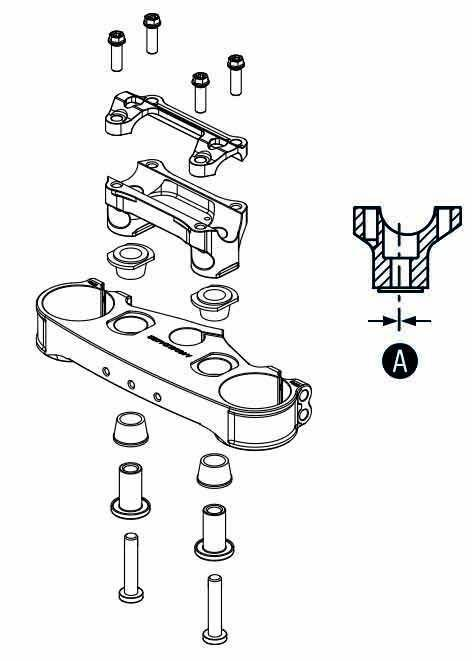

In [8]:
# Display the largest image from page 50 (most likely the procedure diagram)
largest = max(imgs, key=lambda i: i.width * i.height)
print(f"Displaying: {largest.key}  {largest.width}x{largest.height}")
display(IPImage(data=largest.data))

## 6. Pages with no chapter detected

Front matter and back matter are expected to have no chapter. Verify nothing surprising slipped through.

In [9]:
no_chapter = [p for p in pages if p.chapter_num is None]
print(f"Pages without chapter: {len(no_chapter)}")
print(f"Page numbers: {[p.page_num for p in no_chapter]}")
print()
# Show what's on a couple of them
for p in no_chapter[:3]:
    print(f"--- Page {p.page_num} ---")
    print(p.text[:300])
    print()

Pages without chapter: 35
Page numbers: [1, 2, 3, 7, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 374, 377, 378]

--- Page 1 ---
Repair Manual 2026
FE 450
FE 501
FE 501s
Item no.: 3403273en
Douglas Raffle, raffled@gmail.com, 069969/074383

--- Page 2 ---
Douglas Raffle, raffled@gmail.com, 069969/074383

--- Page 3 ---
Introduction
*3403273en*
3403273en
28/01/2026
Introduction
Read the repair manual carefully and completely before starting work.
The vehicle will only be able to meet the demands placed on it in the long run if the specified service work is
performed regularly and properly.
The repair manual was wri

